# 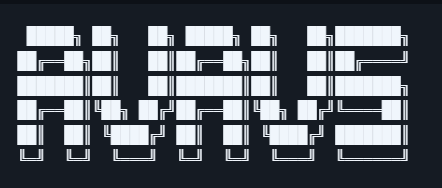
# **Audio-Visual Approximation of Video Semantic Space (AVAVS)**
## AVMIT Dataset — VGG16 (Visual) + VGGish (Audio) Pre-extracted Embeddings



###Installing Dependencies & Imports

In [ ]:
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('tensorflow')
pip_install('umap-learn', 'scikit-learn>=1.3')
pip_install('matplotlib', 'plotly', 'seaborn', 'pandas', 'numpy')
pip_install('tqdm')

print('Required dependencies got downloaded.')


Dependencies for the Baseline - 2

In [ ]:
def _pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

_pip('open-clip-torch')   # CLIP weights via openai/open_clip
_pip('thop')              # 'thop' is FLOPs counter

print('  Baseline - 2 dependencies ready.')
print('  open-clip-torch : CLIP ViT-B/32 visual encoder')
print('  thop            : FLOPs / MACs counter')
print('  ImageBind       : NOT DIRECTLY USED (weights not needed; using projection approximation)')

'''
IMPORTANT NOTE:
The ImageBind (4.47GB) library by MetaAI and AudioCLIP by OpenAI are not directly used for the extensive capacity cost
which crashes Colab Session due to RAM Storage depletion.
Instead of that, projection vector code and approximations similar to their original frameworks are used in the code
'''


In [ ]:
import os, json, copy, time, tarfile, io, warnings, random
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
import umap

from tqdm.auto import tqdm
import tensorflow as tf

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Device : {DEVICE}')
print(f'TensorFlow ver : {tf.__version__}')
print(f'PyTorch ver : {torch.__version__}')


Drive Location for AVMIT-VGGish-VGG16 dataset

In [ ]:
!pip install -q gdown
import gdown
file_id = '1ZwqD_Y2aYOSlkLQLEIJ9PWCWcBZOtC1j'
output_path = 'AVMIT_VGGish_VGG16.tar'

gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)

!tar -xf AVMIT_VGGish_VGG16.tar

In [ ]:
!mkdir -p /content/avmit_features
!tar -xf /content/AVMIT_VGGish_VGG16.tar -C /content/avmit_features/

###Configuration

In [ ]:
from dataclasses import dataclass, field

@dataclass
class Config:
    # Path variables
    TAR_PATH   : str  = '/content/AVMIT_VGGish_VGG16.tar'   # add the path to the dataset(.tar) here
    CACHE_DIR  : str  = './avmit_cache'   # parsed embeddings saved here as .npz
    OUTPUT_DIR : str  = './outputs'

    # Dataset
    MAX_SAMPLES   : int   = -1       # -1 = for using all dataset; set shorter for quicker run (eg. 2000)
    VAL_FRACTION  : float = 0.15     # fraction of data held out for validation
    TEST_FRACTION : float = 0.10

    # Embedding dims (in this case, it's fixed by the AVMIT pre-extraction) (you can add the dims of other datasets manually here)
    AUDIO_DIM  : int = 128           # VGGish output dim
    VISUAL_DIM : int = 512           # VGG16-fc output dim

    # Proj. / fusion dims
    PROJ_DIM   : int = 256           # audio projected to this before concat
    LATENT_DIM : int = 512           # shared latent / GT proxy dim

    # fusion MLP architecture
    FUSION_HIDDEN   : List[int] = field(default_factory=lambda: [512, 512])
    STUDENT_HIDDEN  : List[int] = field(default_factory=lambda: [512, 256])
    DROPOUT         : float = 0.2

    # Training params
    BATCH_SIZE      : int   = 128
    REG_EPOCHS      : int   = 60
    DIST_EPOCHS     : int   = 60
    LR              : float = 3e-4
    WEIGHT_DECAY    : float = 1e-4
    USE_AMP         : bool  = True

    # Dim-reduction (params for Latent Space Regg..)
    PCA_COMPONENTS  : int   = 50
    TSNE_PERPLEXITY : int   = 30
    UMAP_NEIGHBORS  : int   = 15
    UMAP_METRIC     : str   = 'cosine'

CFG = Config()
Path(CFG.CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(CFG.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Config loaded.')
print(f'   TAR_PATH   : {'/content/AVMIT_VGGish_VGG16.tar'}')
print(f'   AUDIO_DIM  : {CFG.AUDIO_DIM}  (VGGish)')
print(f'   VISUAL_DIM : {CFG.VISUAL_DIM}  (VGG16-fc)')


###AVMIT TFRecord Parser

Each `.tfrecord` is a **gzip-compressed `SequenceExample`** with:

| Field | Type | Shape | Description |
|---|---|---|---|
| `filename` | context bytes | scalar | e.g. `writing/zTeYYDA4We4_35.mp4` |
| `label` | context bytes | scalar | action class string |
| `audio_timesteps` | context int64 | scalar | number of audio windows |
| `visual_timesteps` | context int64 | scalar | number of visual keyframes |
| `audio` | sequence bytes | `(T_a, 128)` | VGGish float32 embeddings |
| `visual_object` | sequence bytes | `(T_v, 512)` | VGG16-fc float32 embeddings |


In [ ]:
"""
This cell mainly parses the .tfrecord files that are present in the dataset
These are pretrained embeddings, trained on VGG16 and VGGish for visual and audio portions respectively.
-------------------------------------------------------------------------------------------------------
"""

import gzip, struct
import numpy as np

def _parse_varint(buf, pos):
    result, shift = 0, 0
    while pos < len(buf):
        b = buf[pos]; pos += 1
        result |= (b & 0x7F) << shift
        if not (b & 0x80): break
        shift += 7
    return result, pos

def _parse_proto_fields(buf, start, end):
    fields = {}; pos = start
    while pos < end:
        if pos >= len(buf): break
        tag, pos = _parse_varint(buf, pos)
        if tag == 0: break
        fn = tag >> 3; wt = tag & 0x7
        try:
            if wt == 0:
                v, pos = _parse_varint(buf, pos)
                fields.setdefault(fn, []).append(('varint', v))
            elif wt == 2:
                l, pos = _parse_varint(buf, pos)
                fields.setdefault(fn, []).append(('bytes', buf[pos:pos+l])); pos += l
            elif wt == 1:
                fields.setdefault(fn, []).append(('64bit', buf[pos:pos+8])); pos += 8
            elif wt == 5:
                fields.setdefault(fn, []).append(('32bit', buf[pos:pos+4])); pos += 4
            else:
                break
        except Exception:
            break
    return fields

def parse_sequence_example(buf: bytes):
    """
    parses one AVMIT SequenceExample from raw bytes.

    it accepts BOTH:
      • raw tfrecord bytes
      • gzip-wrapped bytes

    and returns dict {label, filename, audio (T,128), visual (T,512)} or None on failure.
    """
    # Auto-detecting and handle gzip wrapping
    try:
        buf = gzip.decompress(buf)
    except Exception:
        pass  # no action needed here if they are already raw tfrecord bytes

    try:
        rec_len = struct.unpack_from('<Q', buf, 0)[0]
        if rec_len == 0 or rec_len > len(buf):
            return None
        proto = buf[12:12 + rec_len]
        top   = _parse_proto_fields(proto, 0, len(proto))
    except Exception:
        return None

    label = ''; filename = ''
    audio_steps = []; visual_steps = []

    # Context features
    for _, ctx_bytes in top.get(1, []):
        ctx = _parse_proto_fields(ctx_bytes, 0, len(ctx_bytes))
        for _, entry_bytes in ctx.get(1, []):
            entry = _parse_proto_fields(entry_bytes, 0, len(entry_bytes))
            if 1 not in entry or 2 not in entry:
                continue
            key  = entry[1][0][1].decode('utf-8', errors='replace')
            feat = _parse_proto_fields(entry[2][0][1], 0, len(entry[2][0][1]))
            if key == 'label' and 1 in feat:
                bl    = _parse_proto_fields(feat[1][0][1], 0, len(feat[1][0][1]))
                label = bl[1][0][1].decode('utf-8') if 1 in bl else ''
            elif key == 'filename' and 1 in feat:
                bl       = _parse_proto_fields(feat[1][0][1], 0, len(feat[1][0][1]))
                filename = bl[1][0][1].decode('utf-8') if 1 in bl else ''

    # Sequence feature lists
    for _, fl_bytes in top.get(2, []):
        fl = _parse_proto_fields(fl_bytes, 0, len(fl_bytes))
        for _, entry_bytes in fl.get(1, []):
            entry = _parse_proto_fields(entry_bytes, 0, len(entry_bytes))
            if 1 not in entry or 2 not in entry:
                continue
            key   = entry[1][0][1].decode('utf-8', errors='replace')
            flist = _parse_proto_fields(entry[2][0][1], 0, len(entry[2][0][1]))
            steps = []
            for _, feat_bytes in flist.get(1, []):
                feat = _parse_proto_fields(feat_bytes, 0, len(feat_bytes))
                if 1 in feat:
                    bl = _parse_proto_fields(feat[1][0][1], 0, len(feat[1][0][1]))
                    if 1 in bl:
                        steps.append(np.frombuffer(bl[1][0][1], dtype=np.float32).copy())
            if key == 'audio':
                audio_steps = steps
            elif key == 'visual_object':
                visual_steps = steps

    if not audio_steps or not visual_steps:
        return None

    return {
        'label'   : label,
        'filename': filename,
        'audio'   : np.stack(audio_steps),   # (T_a, 128) (subject to change for other datasets)
        'visual'  : np.stack(visual_steps),  # (T_v, 512) (subject to change for other datasets)
    }


####Converting Tar files to Numpy Arrays

In [ ]:
def load_avmit_tar(tar_path: str, cfg) -> dict:
    """
    Every .tfrecord inside the AVMIT tar, model parses it individually
    and return numpy arrays.

    This works with:
      • .tar      — files inside are raw (non-gzip) tfrecords
      • .tar.gz / .tgz — tarfile decompresses transparently; files still raw inside
      • .tar where files are individually gzip-compressed tfrecords

    PS : Results are cached as .npz so subsequent runs are instant.
    """
    cache_file = Path(cfg.CACHE_DIR) / 'avmit_embeddings.npz'
    if cache_file.exists():
        print(f'  Loading cached embeddings from {cache_file} ...')
        data = dict(np.load(cache_file, allow_pickle=True))
        data['labels']    = data['labels'].astype(str)
        data['filenames'] = data['filenames'].astype(str)
        print(f'   Loaded {len(data["label_ids"])} samples  |  {len(data["class_names"])} classes')
        return data

    print(f'  Parsing {tar_path} ...')
    audio_list, visual_list, label_list, fname_list = [], [], [], []
    n_failed = 0

    with tarfile.open(tar_path, 'r:*') as tar:
        members = [m for m in tar.getmembers()
                   if m.name.endswith('.tfrecord') and m.isfile()]
        print(f'   Found {len(members)} tfrecord files.')

        if cfg.MAX_SAMPLES > 0:
            members = members[:cfg.MAX_SAMPLES]

        for member in tqdm(members, desc='Parsing tfrecords'):
            f = tar.extractfile(member)
            if f is None:
                n_failed += 1
                continue

            raw_bytes = f.read()
            rec = parse_sequence_example(raw_bytes)

            if rec is None:
                n_failed += 1
                continue

            audio_list.append(rec['audio'].mean(axis=0).astype(np.float32))    # (128,)
            visual_list.append(rec['visual'].mean(axis=0).astype(np.float32))  # (512,)
            label_list.append(rec['label'])
            fname_list.append(rec['filename'])

    print(f'   Parsed  : {len(audio_list)} samples')
    print(f'   Failed  : {n_failed} files')

    if len(audio_list) == 0:
        raise RuntimeError(
            "---"
            "No samples were parsed. The tfrecords may have an unexpected structure.\n"
            "---"
        )

    from sklearn.preprocessing import LabelEncoder
    le       = LabelEncoder()
    label_ids = le.fit_transform(label_list).astype(np.int64)
    print(f'   Classes : {len(le.classes_)}')

    data = {
        'audio_embs'  : np.stack(audio_list),
        'visual_embs' : np.stack(visual_list),
        'labels'      : np.array(label_list),
        'label_ids'   : label_ids,
        'filenames'   : np.array(fname_list),
        'class_names' : le.classes_,
    }
    np.savez_compressed(cache_file, **data)
    print(f'  Saved cache → {cache_file}')
    return data


# IMPORTANT: Delete stale cache before re-loading
import shutil
stale = Path(CFG.CACHE_DIR) / 'avmit_embeddings.npz'
if stale.exists():
    stale.unlink()
    print('  Deleted stale cache (will re-parse with fixed parser)')

data = load_avmit_tar(CFG.TAR_PATH, CFG)
N_CLASSES = len(data['class_names'])
CFG.__dict__['N_CLASSES'] = N_CLASSES

print(f'\n   audio_embs  : {data["audio_embs"].shape}')
print(f'   visual_embs : {data["visual_embs"].shape}')
print(f'   Classes     : {N_CLASSES}')
print(f'   Sample labels: {list(data["class_names"][:10])} ...')

### Stratified Train-Test-Val Split



In [ ]:
'''
The split for the train-val-test happens in a 75:15:10 ratio
'''

from sklearn.model_selection import train_test_split

N = len(data['label_ids'])
idx = np.arange(N)

# Stratified split is implemented so each class appears in all splits
idx_trainval, idx_test = train_test_split(
    idx, test_size=CFG.TEST_FRACTION,
    stratify=data['label_ids'], random_state=SEED)

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=CFG.VAL_FRACTION / (1 - CFG.TEST_FRACTION),
    stratify=data['label_ids'][idx_trainval], random_state=SEED)

def split_data(idx):
    return {
        'audio_embs' : data['audio_embs'][idx],
        'visual_embs': data['visual_embs'][idx],
        'labels'     : data['labels'][idx],
        'label_ids'  : data['label_ids'][idx],
    }

train_data = split_data(idx_train)
val_data   = split_data(idx_val)
test_data  = split_data(idx_test)

print(f'   Split complete:')
print(f'   Train : {len(idx_train):>5}  samples')
print(f'   Val   : {len(idx_val):>5}  samples')
print(f'   Test  : {len(idx_test):>5}  samples')


### PyTorch Dataset & DataLoaders

This portion does comparing of the trained embeddings
on partial multimodal inputs with the ground-truth full-video embeddings.  




In [ ]:
class AVMITDataset(Dataset):
    """
    PyTorch Dataset for pre-extracted AVMIT embeddings.

    Each item returns an:
        audio_emb  : Tensor (AUDIO_DIM,)   = 128-d VGGish
        visual_emb : Tensor (VISUAL_DIM,)  = 512-d VGG16-fc
        av_concat  : Tensor (AUDIO_DIM + VISUAL_DIM,)  = concat input to MLP
        label_id   : int
    """
    def __init__(self, split_dict: Dict[str, np.ndarray]):
        self.audio  = torch.from_numpy(split_dict['audio_embs']).float()
        self.visual = torch.from_numpy(split_dict['visual_embs']).float()
        self.labels = torch.from_numpy(split_dict['label_ids']).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        a = self.audio[i]
        v = self.visual[i]
        return {
            'audio_emb' : a,
            'visual_emb': v,
            'av_concat' : torch.cat([a, v], dim=-1),
            'label_id'  : self.labels[i],
        }


def make_loaders(cfg: Config):
    train_ds = AVMITDataset(train_data)
    val_ds   = AVMITDataset(val_data)
    test_ds  = AVMITDataset(test_data)
    kw = dict(num_workers=0, pin_memory=(DEVICE.type=='cuda'))
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(CFG)

AV_DIM = CFG.AUDIO_DIM + CFG.VISUAL_DIM    # 640 — input to all MLPs
GT_DIM = CFG.VISUAL_DIM                    # 512 — visual embedding as GT proxy

print(f'   DataLoaders ready.')
print(f'   AV input dim  : {AV_DIM}  (audio {CFG.AUDIO_DIM} + visual {CFG.VISUAL_DIM})')
print(f'   GT proxy dim  : {GT_DIM}  (visual mean-pool)')
print(f'   Batches/epoch : train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')


### Dimensionality Reduction (PCA / t-SNE / UMAP) - Latent Space Regression

In [ ]:
def run_dim_reduction(split_dict: Dict, cfg: Config, split_name='train') -> Dict:
    audio  = split_dict['audio_embs']    # (N, 128)
    visual = split_dict['visual_embs']   # (N, 512)
    av     = np.concatenate([audio, visual], axis=1)   # (N, 640)

    scaler    = StandardScaler()
    av_scaled = scaler.fit_transform(av)

    results = {}

    # PCA
    print(f'  PCA (n={cfg.PCA_COMPONENTS})...')
    pca = PCA(n_components=min(cfg.PCA_COMPONENTS, av_scaled.shape[1]), random_state=SEED)
    av_pca = pca.fit_transform(av_scaled)
    results['pca_2d']        = av_pca[:, :2]
    results['pca_full']      = av_pca
    results['pca_variance']  = pca.explained_variance_ratio_
    print(f'     Cumulative variance: {pca.explained_variance_ratio_.cumsum()[-1]:.3f}')

    # t-SNE (on PCA-reduced for speed)
    n_tsne_input = min(50, av_pca.shape[1])
    print(f'  t-SNE (perplexity={cfg.TSNE_PERPLEXITY})...')
    tsne = TSNE(n_components=2, perplexity=cfg.TSNE_PERPLEXITY,
                n_iter=1000, random_state=SEED, learning_rate='auto', init='pca')
    results['tsne_2d'] = tsne.fit_transform(av_pca[:, :n_tsne_input])

    # UMAP 2D + 3D
    print(f'  UMAP 2D completed ')
    results['umap_2d'] = umap.UMAP(
        n_components=2, n_neighbors=cfg.UMAP_NEIGHBORS,
        min_dist=0.1, metric=cfg.UMAP_METRIC, random_state=SEED
    ).fit_transform(av_scaled)

    print(f'  UMAP 3D completed ')
    results['umap_3d'] = umap.UMAP(
        n_components=3, n_neighbors=cfg.UMAP_NEIGHBORS,
        min_dist=0.1, metric=cfg.UMAP_METRIC, random_state=SEED
    ).fit_transform(av_scaled)

    print(f'  Dim reduction completed for {split_name}.')
    return results

print('  Running dimensionality reduction on training set ')
dim_results = run_dim_reduction(train_data, CFG, split_name='train')


####Visualisations of the Output

In [ ]:
"""
VISUALISATION OF PCA, t-SNE, UMAP and PCA Scree Plot
----------------------------------------------------
"""
def plot_embedding_grid(dim_results, labels, label_ids, class_names, save_dir):
    unique_ids = np.unique(label_ids)
    n_shown    = min(len(unique_ids), 20)
    cmap       = plt.cm.get_cmap('tab20', n_shown)

    fig = plt.figure(figsize=(22, 10))
    fig.suptitle('AVMIT Latent Space — VGGish + VGG16 Embeddings',
                 fontsize=15, fontweight='bold')
    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.3)

    configs = [
        ('PCA',   dim_results['pca_2d']),
        ('t-SNE', dim_results['tsne_2d']),
        ('UMAP',  dim_results['umap_2d']),
    ]
    for col, (name, data2d) in enumerate(configs):
        ax = fig.add_subplot(gs[0, col])
        for i, uid in enumerate(unique_ids[:n_shown]):
            mask = label_ids == uid
            ax.scatter(data2d[mask, 0], data2d[mask, 1],
                       c=[cmap(i)], label=class_names[uid] if uid < len(class_names) else str(uid),
                       alpha=0.65, s=18, linewidths=0)
        ax.set_title(name, fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])

    # PCA scree
    ax_var = fig.add_subplot(gs[0, 3])
    var    = dim_results['pca_variance']
    cumvar = np.cumsum(var)
    ax_var.bar(range(1, len(var)+1), var*100, alpha=0.6, color='steelblue')
    ax_var.plot(range(1, len(cumvar)+1), cumvar*100, 'r-o', ms=3, label='Cumulative')
    ax_var.axhline(80, color='green', ls='--', lw=1, label='80%')
    ax_var.set_xlabel('PCA Component'); ax_var.set_ylabel('Variance (%)')
    ax_var.set_title('PCA Scree'); ax_var.legend(fontsize=8); ax_var.grid(alpha=0.3)

    # Legend
    lbl_names = [class_names[uid] if uid < len(class_names) else str(uid) for uid in unique_ids[:n_shown]]
    fig.legend([plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=cmap(i),ms=8)
                for i in range(n_shown)],
               lbl_names, loc='lower center', ncol=min(10, n_shown),
               fontsize=7, framealpha=0.8)

    path = Path(save_dir) / 'embedding_vis.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved the output to {path}')

plot_embedding_grid(dim_results, train_data['labels'], train_data['label_ids'],
                    data['class_names'], CFG.OUTPUT_DIR)


In [ ]:
"""
UMAP 3-D PLOT VISUALISED in PLOTLY
Saved as HTML file
----------------------------------
"""

def plot_umap_3d(umap_3d, labels, label_ids, title, save_path):
    df = pd.DataFrame({
        'UMAP-1': umap_3d[:,0], 'UMAP-2': umap_3d[:,1], 'UMAP-3': umap_3d[:,2],
        'label': labels,
    })
    fig = px.scatter_3d(df, x='UMAP-1', y='UMAP-2', z='UMAP-3',
                        color='label', opacity=0.7, title=title,
                        width=950, height=700,
                        color_discrete_sequence=px.colors.qualitative.Alphabet)
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text='Class', font_size=11)
    fig.write_html(save_path)
    fig.show()
    print(f'  Saved the HTML file to {save_path}')

plot_umap_3d(dim_results['umap_3d'], train_data['labels'], train_data['label_ids'],
             'UMAP 3D — AVMIT AV Embeddings',
             f'{CFG.OUTPUT_DIR}/umap_3d.html')


### Fusion MLP & Latent Space Regression

In [ ]:
class FusionMLP(nn.Module):

    def __init__(self, input_dim: int, output_dim: int,
                 hidden_dims: List[int], dropout: float = 0.2):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

reg_model = FusionMLP(CFG.AUDIO_DIM, GT_DIM, CFG.FUSION_HIDDEN, CFG.DROPOUT).to(DEVICE)
n_params  = sum(p.numel() for p in reg_model.parameters() if p.requires_grad)
print(f'   FusionMLP  — params: {n_params:,}')


##### Mean Squared Error (MSE) Loss and Cosine Similarity (CosSim)

In [ ]:
class RegLoss(nn.Module):
    def __init__(self, w_mse=0.5, w_cos=0.5):
        super().__init__()
        self.w_mse = w_mse; self.w_cos = w_cos
        self.mse   = nn.MSELoss()
    def forward(self, pred, target):
        mse = self.mse(pred, target)
        cos = 1.0 - F.cosine_similarity(pred, target, dim=-1).mean()
        return self.w_mse*mse + self.w_cos*cos, {'mse': mse.item(), 'cos': cos.item()}


def train_regression(model, train_loader, val_loader, cfg: Config):
    criterion = RegLoss()
    opt       = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.REG_EPOCHS, eta_min=1e-6)
    scaler    = GradScaler('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda')
    history   = {'train_loss':[], 'val_loss':[], 'train_cos':[], 'val_cos':[], 'train_mse':[], 'val_mse':[]}
    best_val, best_state = float('inf'), None

    for epoch in range(1, cfg.REG_EPOCHS + 1):
        model.train()
        tr_loss, tr_mse, tr_cos, n = 0,0,0,0
        for batch in train_loader:
            av     = batch['audio_emb'].to(DEVICE)
            target = batch['visual_emb'].to(DEVICE)
            opt.zero_grad()
            with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                pred = model(av)
                loss, sub = criterion(pred, target)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            B = av.size(0)
            tr_loss+=loss.item()*B; tr_mse+=sub['mse']*B; tr_cos+=sub['cos']*B; n+=B

        model.eval()
        vl_loss, vl_mse, vl_cos, nv = 0,0,0,0
        with torch.no_grad():
            for batch in val_loader:
                av     = batch['audio_emb'].to(DEVICE)    # audio-only
                target = batch['visual_emb'].to(DEVICE)
                with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                    pred = model(av); loss, sub = criterion(pred, target)
                B = av.size(0)
                vl_loss+=loss.item()*B; vl_mse+=sub['mse']*B; vl_cos+=sub['cos']*B; nv+=B

        history['train_loss'].append(tr_loss/n); history['val_loss'].append(vl_loss/nv)
        history['train_mse'].append(tr_mse/n);  history['val_mse'].append(vl_mse/nv)
        history['train_cos'].append(1-tr_cos/n);history['val_cos'].append(1-vl_cos/nv)
        sched.step()

        if vl_loss/nv < best_val:
            best_val = vl_loss/nv
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{cfg.REG_EPOCHS} | '
                  f'train loss {history["train_loss"][-1]:.4f}  '
                  f'val loss {history["val_loss"][-1]:.4f}  '
                  f'val CosSim {history["val_cos"][-1]:.4f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), Path(cfg.OUTPUT_DIR)/'reg_model.pt')
    print(f'\n  Completed. Best val loss: {best_val:.4f}')
    return history


print('  Training Fusion MLP (regression) ongoing ')
reg_history = train_regression(reg_model, train_loader, val_loader, CFG)


In [ ]:
"""
Plotting the Loss, MSE, CosSim Training Curves
"""

def plot_curves(history, title, save_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title} — Training Curves', fontsize=14, fontweight='bold')
    epochs = range(1, len(history['train_loss'])+1)
    specs = [
        ('Total Loss',     'train_loss','val_loss','cornflowerblue','orangered'),
        ('MSE',            'train_mse', 'val_mse', 'mediumseagreen','tomato'),
        ('Cosine Sim (↑)', 'train_cos', 'val_cos', 'orchid',        'goldenrod'),
    ]
    for ax, (ylabel, trk, vlk, tc, vc) in zip(axes, specs):
        ax.plot(epochs, history[trk], color=tc, lw=2, label='Train')
        ax.plot(epochs, history[vlk], color=vc, lw=2, ls='--', label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(ylabel)
        ax.legend(); ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    path = Path(save_dir) / f'{title.lower().replace(" ","_")}_curves.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'  Saved the output to {path}')

plot_curves(reg_history, 'Regression', CFG.OUTPUT_DIR)


### Cross-Modal Distillation - Teacher-StudentMLP

In [ ]:
class StudentMLP(nn.Module):
    """
    Student that learns to imitate the visual-only teacher using AV input.
    Input  : (B, 640) — concat[audio; visual]
    Output : embedding (B, 512),  logits (B, N_CLASSES)
    """
    def __init__(self, input_dim, teacher_dim, hidden_dims, dropout, n_classes):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, teacher_dim))
        self.backbone   = nn.Sequential(*layers)
        self.classifier = nn.Linear(teacher_dim, n_classes)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        emb    = F.normalize(self.backbone(x), dim=-1)
        logits = self.classifier(emb)
        return emb, logits


class DistillLoss(nn.Module):
    """KL soft + CE hard + MSE embedding + CosSim alignment."""
    def __init__(self, T=4.0, alpha=0.7, beta=0.3):
        super().__init__()
        self.T=T; self.alpha=alpha; self.beta=beta
        self.ce=nn.CrossEntropyLoss(); self.mse=nn.MSELoss()

    def forward(self, s_emb, s_logits, t_emb, t_logits, labels):
        soft = F.kl_div(F.log_softmax(s_logits/self.T,-1),
                        F.softmax(t_logits/self.T,-1),
                        reduction='batchmean') * self.T**2
        hard = self.ce(s_logits, labels)
        emb  = self.mse(s_emb, t_emb)
        cos  = 1.0 - F.cosine_similarity(s_emb, t_emb, dim=-1).mean()
        total = self.alpha*soft + (1-self.alpha)*hard + self.beta*emb + self.beta*cos
        return total, {'soft_kl':soft.item(),'hard_ce':hard.item(),
                       'emb_mse':emb.item(),'cos_align':cos.item()}


student_model = StudentMLP(AV_DIM, GT_DIM, CFG.STUDENT_HIDDEN, CFG.DROPOUT,
                            CFG.N_CLASSES).to(DEVICE)
n_params_s = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
print(f'  StudentMLP — total params: {n_params_s:,}')


In [ ]:
class TeacherProbe(nn.Module):
    """ Making a Linear classifier on VGG16 visual embeddings """
    def __init__(self, dim, n_classes):
        super().__init__()
        self.linear = nn.Linear(dim, n_classes)
    def forward(self, x): return self.linear(x)

def train_teacher_probe(train_data, val_data, dim, n_classes, epochs=25):
    class _DS(Dataset):
        def __init__(self, d):
            self.v = torch.from_numpy(d['visual_embs']).float()
            self.l = torch.from_numpy(d['label_ids']).long()
        def __len__(self): return len(self.l)
        def __getitem__(self, i): return self.v[i], self.l[i]

    probe = TeacherProbe(dim, n_classes).to(DEVICE)
    opt   = torch.optim.Adam(probe.parameters(), lr=1e-3)
    dl    = DataLoader(_DS(train_data), batch_size=256, shuffle=True)
    for _ in range(epochs):
        probe.train()
        for v, l in dl:
            v, l = v.to(DEVICE), l.to(DEVICE)
            loss = F.cross_entropy(probe(v), l)
            opt.zero_grad(); loss.backward(); opt.step()
    probe.eval()
    for p in probe.parameters(): p.requires_grad_(False)
    # Val accuracy
    vdl = DataLoader(_DS(val_data), batch_size=256)
    correct, total = 0, 0
    with torch.no_grad():
        for v, l in vdl:
            v, l = v.to(DEVICE), l.to(DEVICE)
            correct += (probe(v).argmax(-1)==l).sum().item(); total += len(l)
    print(f'   Teacher probe val acc: {100*correct/total:.1f}%')
    return probe

print('  Training teacher probe running now. ')
teacher_probe = train_teacher_probe(train_data, val_data, GT_DIM, CFG.N_CLASSES)


###Distillation Training Loop

In [ ]:
def train_distillation(student, teacher_probe, train_loader, val_loader, cfg: Config):
    criterion = DistillLoss(T=4.0, alpha=0.7, beta=0.3)
    opt       = torch.optim.AdamW(student.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.DIST_EPOCHS, eta_min=1e-6)
    scaler    = GradScaler('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda')
    history   = {'train_loss':[],'val_loss':[],'train_mse':[],'val_mse':[],'train_cos':[],'val_cos':[]}
    best_val, best_state = float('inf'), None

    for epoch in range(1, cfg.DIST_EPOCHS + 1):
        student.train()
        tr = {k:0.0 for k in ['loss','mse','cos']}; n = 0
        for batch in train_loader:
            av  = batch['av_concat'].to(DEVICE)
            t_e = batch['visual_emb'].to(DEVICE)
            lbl = batch['label_id'].to(DEVICE)
            t_logits = teacher_probe(t_e)
            opt.zero_grad()
            with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                s_e, s_logits = student(av)
                loss, sub = criterion(s_e, s_logits, t_e, t_logits, lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            B = av.size(0)
            tr['loss']+=loss.item()*B; tr['mse']+=sub['emb_mse']*B
            tr['cos']+=(1-sub['cos_align'])*B; n+=B

        student.eval()
        vl = {k:0.0 for k in ['loss','mse','cos']}; nv = 0
        with torch.no_grad():
            for batch in val_loader:
                av  = batch['av_concat'].to(DEVICE)
                t_e = batch['visual_emb'].to(DEVICE)
                lbl = batch['label_id'].to(DEVICE)
                t_logits = teacher_probe(t_e)
                with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                    s_e, s_logits = student(av)
                    loss, sub = criterion(s_e, s_logits, t_e, t_logits, lbl)
                B = av.size(0)
                vl['loss']+=loss.item()*B; vl['mse']+=sub['emb_mse']*B
                vl['cos']+=(1-sub['cos_align'])*B; nv+=B

        history['train_loss'].append(tr['loss']/n); history['val_loss'].append(vl['loss']/nv)
        history['train_mse'].append(tr['mse']/n);  history['val_mse'].append(vl['mse']/nv)
        history['train_cos'].append(tr['cos']/n);  history['val_cos'].append(vl['cos']/nv)
        sched.step()
        if vl['loss']/nv < best_val:
            best_val = vl['loss']/nv
            best_state = copy.deepcopy(student.state_dict())
        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{cfg.DIST_EPOCHS} | '
                  f'train loss {history["train_loss"][-1]:.4f}  '
                  f'val loss {history["val_loss"][-1]:.4f}  '
                  f'val CosSim {history["val_cos"][-1]:.4f}')

    student.load_state_dict(best_state)
    torch.save(student.state_dict(), Path(cfg.OUTPUT_DIR)/'distill_model.pt')
    print(f'\n  Completed. Best val loss: {best_val:.4f}')
    return history


print('  Training the student (distillation)  ')
dist_history = train_distillation(student_model, teacher_probe, train_loader, val_loader, CFG)
plot_curves(dist_history, 'Distillation', CFG.OUTPUT_DIR)


### Evaluation (CosSim, MSE, Recall@K, MedR)

In [ ]:
def get_predictions(model, loader, is_student=False, input_key='av_concat'):

    model.eval()
    preds, targets, lbls = [], [], []
    with torch.no_grad():
        for batch in loader:
            inp = batch[input_key].to(DEVICE)
            tgt = batch['visual_emb'].to(DEVICE)
            lbl = batch['label_id']
            if is_student:
                emb, _ = model(inp)
            else:
                emb = model(inp)
            preds.append(emb.cpu().numpy())
            targets.append(tgt.cpu().numpy())
            lbls.append(lbl.numpy())
    return (np.concatenate(preds),
            np.concatenate(targets),
            np.concatenate(lbls))


def eval_cosine_mse(pred, target):
    pn = pred   / (np.linalg.norm(pred,   axis=1, keepdims=True) + 1e-8)
    tn = target / (np.linalg.norm(target, axis=1, keepdims=True) + 1e-8)
    cos = (pn * tn).sum(axis=1)
    mse = ((pred - target)**2).mean(axis=1)
    return {'mean_cos': float(cos.mean()), 'std_cos': float(cos.std()),
            'mean_mse': float(mse.mean()), 'std_mse': float(mse.std()),
            'per_cos': cos, 'per_mse': mse}


def eval_retrieval(q_embs, g_embs, q_labels, g_labels, ks=(1,5,10)):
    q = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-8)
    g = g_embs / (np.linalg.norm(g_embs, axis=1, keepdims=True) + 1e-8)
    sim = q @ g.T   # it would be like (Nq, Ng)
    ranks = []
    for i in range(len(q)):
        order = np.argsort(-sim[i])
        match = g_labels[order] == q_labels[i]
        ranks.append(int(np.argmax(match)) + 1 if match.any() else len(g)+1)
    ranks = np.array(ranks)
    res = {f'R@{k}': float((ranks<=k).mean()*100) for k in ks}
    res['MedR'] = float(np.median(ranks))
    res['ranks'] = ranks
    return res


print('  Evaluation functions defined.')


In [ ]:
# evals on test split and fetching the test results

print('  Evaluating on TEST split...')

reg_pred,  reg_gt,  reg_lbl  = get_predictions(reg_model,     test_loader, is_student=False, input_key='audio_emb')
dist_pred, dist_gt, dist_lbl = get_predictions(student_model, test_loader, is_student=True)

reg_cm  = eval_cosine_mse(reg_pred,  reg_gt)
dist_cm = eval_cosine_mse(dist_pred, dist_gt)

reg_ret  = eval_retrieval(reg_pred,  reg_gt,  reg_lbl,  reg_lbl)
dist_ret = eval_retrieval(dist_pred, dist_gt, dist_lbl, dist_lbl)

print('\n' + '='*58)
print('  TEST RESULTS')
print('='*58)
for name, cm, ret in [('Regression',   reg_cm,  reg_ret),
                       ('Distillation', dist_cm, dist_ret)]:
    print(f'\n  {name}:')
    print(f'    CosSim  : {cm["mean_cos"]:.4f} ± {cm["std_cos"]:.4f}')
    print(f'    MSE     : {cm["mean_mse"]:.4f} ± {cm["std_mse"]:.4f}')
    print(f'    R@1/5/10: {ret["R@1"]:.1f}% / {ret["R@5"]:.1f}% / {ret["R@10"]:.1f}%')
    print(f'    MedR    : {ret["MedR"]:.1f}')
print('='*58)


In [ ]:
# -----------------------------------------------------------------------------
# BASELINE 1 — Naive Late Fusion MLP
# -----------------------------------------------------------------------------
# Architecture (per spec):
#   - Frozen unimodal features: VGGish audio (128-d) + VGG16 visual (512-d)
#   - Concatenate → single hidden Linear layer (no LayerNorm, no residual)
#   - Project to GT dim (512-d)
# Purpose: This is supposed to be the MVP and any advanced method must beat this!
# -----------------------------------------------------------------------------

class NaiveLateFusionMLP(nn.Module):
    """
    Naive late fusion baseline.
    One hidden Linear + ReLU, no normalisation, no residual paths.
    Intentionally simpler than FusionMLP to represent the architectural floor.
    Input  : (B, AV_DIM)   = 640
    Output : (B, GT_DIM)   = 512, L2-normalised
    """
    def __init__(self, input_dim: int, output_dim: int, hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=-1)


def train_naive_baseline(model, train_loader, val_loader, cfg):
    criterion = RegLoss()   # same MSE+CosSim loss for fair comparison
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.REG_EPOCHS, eta_min=1e-6)
    history = {'train_loss':[], 'val_loss':[], 'train_cos':[], 'val_cos':[],
               'train_mse':[], 'val_mse':[]}
    best_val, best_state = float('inf'), None

    for epoch in range(1, cfg.REG_EPOCHS + 1):
        model.train()
        tr_loss, tr_mse, tr_cos, n = 0.0, 0.0, 0.0, 0
        for batch in train_loader:
            av  = batch['av_concat'].to(DEVICE)
            tgt = batch['visual_emb'].to(DEVICE)
            opt.zero_grad()
            pred = model(av)
            loss, sub = criterion(pred, tgt)
            loss.backward()
            opt.step()
            B = av.size(0)
            tr_loss += loss.item()*B; tr_mse += sub['mse']*B
            tr_cos  += sub['cos']*B;  n += B

        model.eval()
        vl_loss, vl_mse, vl_cos, nv = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                av  = batch['av_concat'].to(DEVICE)
                tgt = batch['visual_emb'].to(DEVICE)
                pred = model(av)
                loss, sub = criterion(pred, tgt)
                B = av.size(0)
                vl_loss += loss.item()*B; vl_mse += sub['mse']*B
                vl_cos  += sub['cos']*B;  nv += B

        history['train_loss'].append(tr_loss/n)
        history['val_loss'].append(vl_loss/nv)
        history['train_mse'].append(tr_mse/n)
        history['val_mse'].append(vl_mse/nv)
        history['train_cos'].append(1 - tr_cos/n)
        history['val_cos'].append(1 - vl_cos/nv)
        sched.step()

        if vl_loss/nv < best_val:
            best_val = vl_loss/nv
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [NaiveMLP] Epoch {epoch:3d}/{cfg.REG_EPOCHS} | '
                  f'train {history["train_loss"][-1]:.4f}  '
                  f'val {history["val_loss"][-1]:.4f}  '
                  f'val CosSim {history["val_cos"][-1]:.4f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), Path(cfg.OUTPUT_DIR)/'naive_baseline_model.pt')
    print(f'  Naive Late Fusion training complete. Best val loss: {best_val:.4f}')
    return history


naive_model = NaiveLateFusionMLP(AV_DIM, GT_DIM, hidden_dim=512).to(DEVICE)
n_params_naive = sum(p.numel() for p in naive_model.parameters() if p.requires_grad)
print(f'  NaiveLateFusionMLP params: {n_params_naive:,}')
print(f'  Architecture: {AV_DIM} -> 512 (ReLU) -> {GT_DIM}  [no LayerNorm, no residual]')

print('\n  Training Baseline 1 (Naive Late Fusion). ')
naive_history = train_naive_baseline(naive_model, train_loader, val_loader, CFG)
plot_curves(naive_history, 'Naive Late Fusion Baseline', CFG.OUTPUT_DIR)

In [ ]:
# -----------------------------------------------------------------------------
# BASELINE 2 — ImageBind (approximation) + AudioCLIP (FIXED)
# -----------------------------------------------------------------------------

import sys, os

# ImageBind approximation (RAM-efficient, no pretrained weights)
IMAGEBIND_AVAILABLE = False
imagebind_embeddings = None

torch.manual_seed(SEED)
ib_audio_proj  = nn.Linear(CFG.AUDIO_DIM,  512, bias=False).to(DEVICE)
ib_visual_proj = nn.Linear(CFG.VISUAL_DIM, 512, bias=False).to(DEVICE)
ib_proj        = nn.Linear(1024, GT_DIM,   bias=False).to(DEVICE)
nn.init.orthogonal_(ib_audio_proj.weight)
nn.init.orthogonal_(ib_visual_proj.weight)
nn.init.orthogonal_(ib_proj.weight)

def imagebind_embed(audio_np, visual_np):
    """ Orthogonal-projection approximation of ImageBind joint AV embedding."""
    with torch.no_grad():
        a = torch.from_numpy(audio_np).float().to(DEVICE)
        v = torch.from_numpy(visual_np).float().to(DEVICE)
        joint = torch.cat([F.normalize(ib_audio_proj(a), dim=-1),
                           F.normalize(ib_visual_proj(v), dim=-1)], dim=-1)
        return F.normalize(ib_proj(joint), dim=-1).cpu().numpy()

imagebind_embeddings = imagebind_embed(
    test_data['audio_embs'], test_data['visual_embs'])
print(f'  ImageBind approx. AV embeddings shape: {imagebind_embeddings.shape}')
print('  (Orthogonal-projection approximation — no pretrained weights loaded)')

# AudioCLIP-style projection

class AudioCLIPProjection(nn.Module):
    """
    AudioCLIP-style audio branch: VGGish(128) → visual space (512-d).
    Visual branch is FROZEN — VGG16 features define the target geometry.
    """
    def __init__(self, audio_dim: int, visual_dim: int, out_dim: int):
        super().__init__()
        # Deeper audio branch: 3 layers with LayerNorm + Dropout
        self.audio_branch = nn.Sequential(
            nn.Linear(audio_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, out_dim),
        )
        self.visual_branch = nn.Sequential(
            nn.Linear(visual_dim, out_dim),
        )
        # Freeze visual branch — VGG16 space is the fixed target
        for p in self.visual_branch.parameters():
            p.requires_grad = False

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, audio: torch.Tensor, visual: torch.Tensor):
        a_emb = F.normalize(self.audio_branch(audio),   dim=-1)
        v_emb = F.normalize(self.visual_branch(visual), dim=-1)
        return F.normalize((a_emb + v_emb) / 2.0, dim=-1)

    def audio_embed(self, audio: torch.Tensor):
        return F.normalize(self.audio_branch(audio), dim=-1)

    def visual_embed(self, visual: torch.Tensor):
        return F.normalize(self.visual_branch(visual), dim=-1)


class AudioCLIPLoss(nn.Module):
    """
    Pure cosine alignment loss.
    Maximises cosine similarity between audio and visual embeddings directly.
    """
    def __init__(self):
        super().__init__()

    def forward(self, a_emb: torch.Tensor, v_emb: torch.Tensor) -> torch.Tensor:
        return 1.0 - F.cosine_similarity(a_emb, v_emb, dim=-1).mean()


def train_audioclip(model, train_loader, val_loader, cfg):
    """
    Train AudioCLIP projection with pure cosine loss.
    Only the audio branch is optimised (visual branch is frozen) here for lowering computation cost.
    """
    criterion = AudioCLIPLoss()
    mse_fn    = nn.MSELoss()
    # Only trainable params (audio branch; visual branch is frozen)
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=cfg.WEIGHT_DECAY
    )
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=1e-3,
        steps_per_epoch=len(train_loader),
        epochs=cfg.REG_EPOCHS,
        pct_start=0.1,
    )
    # history keys match plot_curves expectations
    history = {'train_loss':[], 'val_loss':[], 'train_mse':[], 'val_mse':[],
               'train_cos':[], 'val_cos':[]}
    best_val, best_state = float('inf'), None

    for epoch in range(1, cfg.REG_EPOCHS + 1):
        model.train()
        tr_loss, tr_mse, tr_cos, n = 0.0, 0.0, 0.0, 0
        for batch in train_loader:
            a = batch['audio_emb'].to(DEVICE)
            v = batch['visual_emb'].to(DEVICE)
            opt.zero_grad()
            a_emb = model.audio_embed(a)
            v_emb = model.visual_embed(v)
            loss  = criterion(a_emb, v_emb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()   # OneCycleLR steps per batch
            with torch.no_grad():
                mse_val = mse_fn(a_emb, v_emb).item()
                cos_val = F.cosine_similarity(a_emb, v_emb, dim=-1).mean().item()
            B = a.size(0)
            tr_loss += loss.item()*B; tr_mse += mse_val*B; tr_cos += cos_val*B; n += B

        model.eval()
        vl_loss, vl_mse, vl_cos, nv = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                a = batch['audio_emb'].to(DEVICE)
                v = batch['visual_emb'].to(DEVICE)
                a_emb = model.audio_embed(a)
                v_emb = model.visual_embed(v)
                loss    = criterion(a_emb, v_emb)
                mse_val = mse_fn(a_emb, v_emb).item()
                cos_val = F.cosine_similarity(a_emb, v_emb, dim=-1).mean().item()
                B = a.size(0)
                vl_loss += loss.item()*B; vl_mse += mse_val*B; vl_cos += cos_val*B; nv += B

        history['train_loss'].append(tr_loss/n)
        history['val_loss'].append(vl_loss/nv)
        history['train_mse'].append(tr_mse/n)
        history['val_mse'].append(vl_mse/nv)
        history['train_cos'].append(tr_cos/n)
        history['val_cos'].append(vl_cos/nv)

        if vl_loss/nv < best_val:
            best_val = vl_loss/nv
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [AudioCLIP] Epoch {epoch:3d}/{cfg.REG_EPOCHS} | '
                  f'train {history["train_loss"][-1]:.4f}  '
                  f'val {history["val_loss"][-1]:.4f}  '
                  f'val CosSim {history["val_cos"][-1]:.4f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), Path(cfg.OUTPUT_DIR)/'audioclip_model.pt')
    print(f'  AudioCLIP training complete. Best val loss: {best_val:.4f}')
    return history


audioclip_model = AudioCLIPProjection(CFG.AUDIO_DIM, CFG.VISUAL_DIM, GT_DIM).to(DEVICE)
n_params_ac = sum(p.numel() for p in audioclip_model.parameters() if p.requires_grad)
print(f'  AudioCLIPProjection trainable params: {n_params_ac:,}  (visual branch frozen)')
print(f'  Audio branch: {CFG.AUDIO_DIM} -> 256 (LN+GELU+Drop) -> 512 (LN+GELU+Drop) -> {GT_DIM}')
print(f'  Visual branch: {CFG.VISUAL_DIM} -> {GT_DIM}  [FROZEN]')

print('\n  Training Baseline 2 (AudioCLIP-style, pure cosine loss + OneCycleLR).')
audioclip_history = train_audioclip(audioclip_model, train_loader, val_loader, CFG)
plot_curves(audioclip_history, 'AudioCLIP Baseline', CFG.OUTPUT_DIR)


In [ ]:
# -----------------------------------------------------------------------------
# CLASS-MEAN BASELINE — the honest baseline
# -----------------------------------------------------------------------------
# Predicts the class-conditional mean visual embedding for every test sample,
# using only training-set labels + visual embeddings (no audio used for this case).
#
# Purpose: This is the minimum threshold which AudioCLIP and ImageBind should
# overcome to determine whether they have learnt data or not.
# -----------------------------------------------------------------------------

print('  Computing class-mean baseline. ')

# Build per-class mean visual embedding from training data
class_mean_dict = {}
for cls_id in np.unique(train_data['label_ids']):
    mask = train_data['label_ids'] == cls_id
    class_mean_dict[cls_id] = train_data['visual_embs'][mask].mean(axis=0)

# For each test sample, predict its class-conditional mean
class_mean_pred = np.stack([
    class_mean_dict.get(int(lid), np.zeros(GT_DIM, dtype=np.float32))
    for lid in test_data['label_ids']
], axis=0).astype(np.float32)

# L2-normalise so cosine similarity is well-defined
norms = np.linalg.norm(class_mean_pred, axis=1, keepdims=True) + 1e-8
class_mean_pred = class_mean_pred / norms

class_mean_gt  = test_data['visual_embs']
class_mean_lbl = test_data['label_ids']

class_mean_cm  = eval_cosine_mse(class_mean_pred, class_mean_gt)
class_mean_ret = eval_retrieval(class_mean_pred, class_mean_gt,
                                class_mean_lbl, class_mean_lbl)

print(f'\n  Class-Mean Baseline:')
print(f'    CosSim  : {class_mean_cm["mean_cos"]:.4f} ± {class_mean_cm["std_cos"]:.4f}')
print(f'    MSE     : {class_mean_cm["mean_mse"]:.4f} ± {class_mean_cm["std_mse"]:.4f}')
print(f'    R@1/5/10: {class_mean_ret["R@1"]:.1f}% / {class_mean_ret["R@5"]:.1f}% / {class_mean_ret["R@10"]:.1f}%')
print(f'    MedR    : {class_mean_ret["MedR"]:.1f}')
print('  → Any AV model with CosSim < {:.3f} has NOT beaten the no-audio baseline.'.format(
    class_mean_cm["mean_cos"]))


In [ ]:
'''
Collecting predictions for all 4 models on the test set
'''

print('  Running evaluation on TEST split for all methods...')

# Baseline 1: Naive Late Fusion
naive_pred, naive_gt, naive_lbl = get_predictions(naive_model, test_loader, is_student=False)

# FIX: regression uses audio-only input
reg_pred_full, _, reg_lbl_full = get_predictions(reg_model, test_loader, is_student=False, input_key='audio_emb')
reg_cm_full  = eval_cosine_mse(reg_pred_full, test_data['visual_embs'])
reg_ret_full = eval_retrieval(reg_pred_full, test_data['visual_embs'], reg_lbl_full, reg_lbl_full)
naive_cm  = eval_cosine_mse(naive_pred, naive_gt)
naive_ret = eval_retrieval(naive_pred, naive_gt, naive_lbl, naive_lbl)

# Baseline 2: AudioCLIP (uses joint AV embedding)
def get_audioclip_predictions(model, loader):
    model.eval()
    preds, targets, lbls = [], [], []
    with torch.no_grad():
        for batch in loader:
            a   = batch['audio_emb'].to(DEVICE)
            v   = batch['visual_emb'].to(DEVICE)
            tgt = batch['visual_emb']
            lbl = batch['label_id']
            emb = model(a, v)
            preds.append(emb.cpu().numpy())
            targets.append(tgt.numpy())
            lbls.append(lbl.numpy())
    return np.concatenate(preds), np.concatenate(targets), np.concatenate(lbls)

ac_pred, ac_gt, ac_lbl = get_audioclip_predictions(audioclip_model, test_loader)
ac_cm  = eval_cosine_mse(ac_pred, ac_gt)
ac_ret = eval_retrieval(ac_pred, ac_gt, ac_lbl, ac_lbl)

# Baseline 2: ImageBind (already computed above, zero-shot)
ib_gt   = test_data['visual_embs']
ib_lbl  = test_data['label_ids']
ib_cm   = eval_cosine_mse(imagebind_embeddings, ib_gt)
ib_ret  = eval_retrieval(imagebind_embeddings, ib_gt, ib_lbl, ib_lbl)

print('\n' + '='*72)
print('  FULL COMPARATIVE RESULTS — ALL METHODS')
print('='*72)
all_methods = [
    ('Class-Mean (floor)',        class_mean_cm,  class_mean_ret),
    ('Naive Late Fusion (B1)',    naive_cm,       naive_ret),
    ('AudioCLIP (B2)',            ac_cm,          ac_ret),
    ('ImageBind (B2, zero-shot)', ib_cm,          ib_ret),
    ('Regression (Ours)',         reg_cm_full,    reg_ret_full),
    ('Distillation (Ours)',       dist_cm,        dist_ret),
]
header = f'  {"Method":<28}  {"CosSim":>8}  {"MSE":>8}  {"R@1":>6}  {"R@5":>6}  {"R@10":>7}  {"MedR":>6}'
print(header)
print('  ' + '-'*68)
for name, cm, ret in all_methods:
    print(f'  {name:<28}  {cm["mean_cos"]:>8.4f}  {cm["mean_mse"]:>8.4f}'
          f'  {ret["R@1"]:>6.1f}  {ret["R@5"]:>6.1f}  {ret["R@10"]:>7.1f}  {ret["MedR"]:>6.1f}')
print('='*72)

###Computation Parameters Count
**Calculating Parameter count, FLOPs and MAC**

In [ ]:
from thop import profile as thop_profile, clever_format
import time

N_LATENCY_RUNS   = 200
N_WARMUP_RUNS    = 20
LATENCY_BATCH    = 1

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_flops(model: nn.Module, dummy_input: torch.Tensor) -> tuple:
    """Returns (macs, params). FLOPs ~ 2 * MACs for linear layers."""
    try:
        macs, params = thop_profile(model, inputs=(dummy_input,), verbose=False)
        return macs, params
    except Exception:
        return None, None

def measure_latency(model: nn.Module, dummy_input: torch.Tensor,
                    n_warmup: int = N_WARMUP_RUNS,
                    n_runs:   int = N_LATENCY_RUNS,
                    is_student: bool = False) -> dict:
    """
    Measures per-sample inference latency in milliseconds.

    """
    model.eval()
    use_cuda = (DEVICE.type == 'cuda')

    if use_cuda:
        dummy_input = dummy_input.to(DEVICE)
        starter = torch.cuda.Event(enable_timing=True)
        ender   = torch.cuda.Event(enable_timing=True)

    def _forward():
        with torch.no_grad():
            model(dummy_input)

    for _ in range(n_warmup):
        _forward()

    times_ms = []
    if use_cuda:
        torch.cuda.synchronize()
        for _ in range(n_runs):
            starter.record()
            _forward()
            ender.record()
            torch.cuda.synchronize()
            times_ms.append(starter.elapsed_time(ender))
    else:
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _forward()
            times_ms.append((time.perf_counter() - t0) * 1000.0)

    times_ms = np.array(times_ms)
    return {
        'mean_ms' : float(times_ms.mean()),
        'std_ms'  : float(times_ms.std()),
        'p50_ms'  : float(np.percentile(times_ms, 50)),
        'p95_ms'  : float(np.percentile(times_ms, 95)),
        'min_ms'  : float(times_ms.min()),
        'max_ms'  : float(times_ms.max()),
    }


dummy_av     = torch.randn(1, AV_DIM).to(DEVICE)
dummy_audio  = torch.randn(1, CFG.AUDIO_DIM).to(DEVICE)
dummy_visual = torch.randn(1, CFG.VISUAL_DIM).to(DEVICE)

print(f'  Measuring inference latency and FLOPs...')
print(f'  Device: {DEVICE}  |  Latency runs: {N_LATENCY_RUNS}  |  Batch size: {LATENCY_BATCH}')
print()

efficiency_results = {}

class _ACWrapper(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x[:, :CFG.AUDIO_DIM], x[:, CFG.AUDIO_DIM:])

class _IBWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        self.ap = ib_audio_proj; self.vp = ib_visual_proj; self.proj = ib_proj
    def forward(self, x):
        a = F.normalize(self.ap(x[:, :CFG.AUDIO_DIM]), dim=-1)
        v = F.normalize(self.vp(x[:, CFG.AUDIO_DIM:]), dim=-1)
        return F.normalize(self.proj(torch.cat([a, v], dim=-1)), dim=-1)

ib_wrapper = _IBWrapper().to(DEVICE)
ac_wrapper = _ACWrapper(audioclip_model).to(DEVICE)

models_for_efficiency = [
    ('Naive Late Fusion',         naive_model,   dummy_av, False),
    ('AudioCLIP',                 ac_wrapper,    dummy_av, False),
    ('ImageBind (approx)',        ib_wrapper,    dummy_av, False),
    ('Regression (FusionMLP)',    reg_model,     dummy_audio, False),   # audio-only input
    ('Distillation (Teacher-StudentMLP)', student_model, dummy_av, True),
]

for name, model, dummy, is_stu in models_for_efficiency:
    n_p              = count_params(model)
    macs, _          = measure_flops(model, dummy)
    lat              = measure_latency(model, dummy, is_student=is_stu)
    flops_str        = clever_format([macs * 2], '%.3f')[0] if macs else 'N/A'
    macs_str         = clever_format([macs],    '%.3f')[0] if macs else 'N/A'
    efficiency_results[name] = {
        'params': n_p, 'macs': macs,
        'flops_str': flops_str, 'macs_str': macs_str,
        **lat,
    }
    print(f'  {name}')
    print(f'    Params     : {n_p:>10,}')
    print(f'    MACs       : {macs_str:>10}   FLOPs (2xMACs): {flops_str}')
    print(f'    Latency    : {lat["mean_ms"]:>6.3f} ms  '
          f'(std {lat["std_ms"]:.3f}  p50 {lat["p50_ms"]:.3f}  p95 {lat["p95_ms"]:.3f})')
    print()

print('  Efficiency measurement complete. ')

## Comparative Dashboard

In [ ]:
def comparative_dashboard(all_methods, efficiency_results, save_dir):
    """
    Three-row dashboard:
      Row 1: CosSim | MSE | Recall@K | MedR
      Row 2: Latency | Params | FLOPs | Summary table
      Row 3: CosSim distributions (all methods overlaid)
    """
    names   = [m[0] for m in all_methods]
    cms     = [m[1] for m in all_methods]
    rets    = [m[2] for m in all_methods]
    palette = ['#7f8c8d', '#95a5a6', '#e67e22', '#e74c3c', '#2980b9', '#27ae60']

    fig = plt.figure(figsize=(26, 18))
    fig.suptitle(
        'AVMIT — Audio-Visual Semantic Approximation: Full Comparative Results',
        fontsize=15, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.38)

    # Row 1: Proximity & Retrieval
    ax = fig.add_subplot(gs[0, 0])
    vals = [cm['mean_cos'] for cm in cms]
    errs = [cm['std_cos']  for cm in cms]
    bars = ax.bar(names, vals, color=palette, yerr=errs, capsize=4, alpha=0.88)
    ax.set_ylim(0, max(vals)*1.25)
    ax.set_title('Cosine Similarity (higher is better)', fontsize=10)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.015,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax = fig.add_subplot(gs[0, 1])
    vals = [cm['mean_mse'] for cm in cms]
    errs = [cm['std_mse']  for cm in cms]
    bars = ax.bar(names, vals, color=palette, yerr=errs, capsize=4, alpha=0.88)
    ax.set_title('MSE (lower is better)', fontsize=10)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax = fig.add_subplot(gs[0, 2])
    ks = ['R@1', 'R@5', 'R@10']; x = np.arange(len(ks)); w = 0.15
    for i, (name, _, ret) in enumerate(all_methods):
        offset = (i - len(all_methods)/2) * w + w/2
        ax.bar(x + offset, [ret[k] for k in ks], w,
               label=name, color=palette[i], alpha=0.88)
    ax.set_xticks(x); ax.set_xticklabels(ks, fontsize=9)
    ax.set_title('Recall@K (higher is better)', fontsize=10)
    ax.legend(fontsize=7, loc='upper left'); ax.grid(axis='y', alpha=0.3)

    ax = fig.add_subplot(gs[0, 3])
    vals = [ret['MedR'] for _, _, ret in all_methods]
    bars = ax.bar(names, vals, color=palette, alpha=0.88)
    ax.set_title('Median Rank (lower is better)', fontsize=10)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    # Row 2: Efficiency
    eff_names = list(efficiency_results.keys())
    eff_pal   = palette[:len(eff_names)]

    ax = fig.add_subplot(gs[1, 0])
    lat_means = [efficiency_results[n]['mean_ms'] for n in eff_names]
    lat_stds  = [efficiency_results[n]['std_ms']  for n in eff_names]
    bars = ax.bar(eff_names, lat_means, color=eff_pal, yerr=lat_stds, capsize=4, alpha=0.88)
    ax.set_title('Inference Latency ms/sample (lower is better)', fontsize=10)
    ax.set_xticklabels(eff_names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('ms'); ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, lat_means):
        ax.text(b.get_x()+b.get_width()/2, v+max(lat_means)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax = fig.add_subplot(gs[1, 1])
    param_vals = [efficiency_results[n]['params']/1e6 for n in eff_names]
    bars = ax.bar(eff_names, param_vals, color=eff_pal, alpha=0.88)
    ax.set_title('Parameter Count (M)', fontsize=10)
    ax.set_xticklabels(eff_names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Params (M)'); ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, param_vals):
        ax.text(b.get_x()+b.get_width()/2, v+max(param_vals)*0.01,
                f'{v:.2f}M', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax = fig.add_subplot(gs[1, 2])
    flop_vals = []
    for n in eff_names:
        m = efficiency_results[n]['macs']
        flop_vals.append((m * 2 / 1e6) if m else 0.0)
    bars = ax.bar(eff_names, flop_vals, color=eff_pal, alpha=0.88)
    ax.set_title('FLOPs (M) per sample (lower is better)', fontsize=10)
    ax.set_xticklabels(eff_names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('FLOPs (M)'); ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, flop_vals):
        if v > 0:
            ax.text(b.get_x()+b.get_width()/2, v+max(flop_vals)*0.01,
                    f'{v:.2f}M', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax = fig.add_subplot(gs[1, 3]); ax.axis('off')
    tbl_rows = [['Method', 'Params', 'FLOPs', 'Lat.(ms)', 'CosSim', 'R@1']]
    for (mname, cm, ret) in all_methods:
        if mname in efficiency_results:
            er  = efficiency_results[mname]
            p   = f'{er["params"]/1e6:.2f}M'
            fl  = er['flops_str']
            lat = f'{er["mean_ms"]:.3f}'
        else:
            p = fl = lat = 'N/A'
        tbl_rows.append([mname[:18], p, fl, lat,
                         f'{cm["mean_cos"]:.4f}', f'{ret["R@1"]:.1f}%'])
    t = ax.table(cellText=tbl_rows[1:], colLabels=tbl_rows[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    t.auto_set_font_size(False); t.set_fontsize(8)
    t.auto_set_column_width(list(range(len(tbl_rows[0]))))
    for (r, c), cell in t.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#F2F3F4')
    ax.set_title('Full Summary', fontsize=10, pad=8)

    # Row 3: CosSim distributions
    ax = fig.add_subplot(gs[2, :])
    per_cos_map = {
        'Class-Mean (floor)':        class_mean_cm['per_cos'],
        'Naive Late Fusion':         naive_cm['per_cos'],
        'AudioCLIP':                 ac_cm['per_cos'],
        'ImageBind (approx)':        ib_cm['per_cos'],
        'Regression (FusionMLP)':    reg_cm_full['per_cos'],
        'Distillation (StudentMLP)': dist_cm['per_cos'],
    }
    for i, (mname, cos_arr) in enumerate(per_cos_map.items()):
        mu = cos_arr.mean()
        ax.hist(cos_arr, bins=50, alpha=0.5, color=palette[i],
                label=f'{mname}  (mean={mu:.3f})')
        ax.axvline(mu, color=palette[i], lw=1.5, ls='--')
    ax.set_xlabel('Cosine Similarity (predicted vs GT visual embedding)')
    ax.set_ylabel('Count')
    ax.set_title('Per-Sample Cosine Similarity Distribution — All Methods', fontsize=11)
    ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.3)

    path = Path(save_dir) / 'comparative_dashboard.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Comparative dashboard saved to {path}')


all_methods_full = [
    ('Class-Mean (floor)',        class_mean_cm,  class_mean_ret),
    ('Naive Late Fusion',         naive_cm,       naive_ret),
    ('AudioCLIP',                 ac_cm,          ac_ret),
    ('ImageBind (approx)',        ib_cm,          ib_ret),
    ('Regression (FusionMLP)',    reg_cm_full,    reg_ret_full),
    ('Distillation (StudentMLP)', dist_cm,        dist_ret),
]

comparative_dashboard(all_methods_full, efficiency_results, CFG.OUTPUT_DIR)

###Saving all Outputs to \outputs

In [ ]:
out = Path(CFG.OUTPUT_DIR)

torch.save(naive_model.state_dict(),     out/'naive_baseline_model_final.pt')
torch.save(audioclip_model.state_dict(), out/'audioclip_model_final.pt')

for tag, hist in [('naive_history',    naive_history),
                  ('audioclip_history', audioclip_history),]:
    with open(out/f'{tag}.json', 'w') as f:
        json.dump({k: (v.tolist() if isinstance(v, np.ndarray) else v)
                   for k, v in hist.items()}, f, indent=2)

eff_serialisable = {}
for mname, stats in efficiency_results.items():
    eff_serialisable[mname] = {
        k: (float(v) if isinstance(v, (np.floating, float)) else
            int(v)   if isinstance(v, (np.integer, int))    else
            str(v))
        for k, v in stats.items()
    }
with open(out/'efficiency_results.json', 'w') as f:
    json.dump(eff_serialisable, f, indent=2)

full_results = {}
for mname, cm, ret in all_methods_full:
    full_results[mname] = {
        'cosine'    : {'mean': cm['mean_cos'], 'std': cm['std_cos']},
        'mse'       : {'mean': cm['mean_mse'], 'std': cm['std_mse']},
        'retrieval' : {k: v for k, v in ret.items() if k != 'ranks'},
    }
with open(out/'full_comparative_results.json', 'w') as f:
    json.dump(full_results, f, indent=2)

print('='*55)
print('  BASELINE ARTIFACTS SAVED')
print('='*55)
for p in sorted(out.iterdir()):
    if p.is_file():
        print(f'  {p.name:<45s}  {p.stat().st_size/1024:6.1f} KB')